<a href="https://colab.research.google.com/github/devn-cmd/Resume-Matcher/blob/main/resume_matcher_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resume Screening & Skill Matching — End-to-End Demo

This notebook runs the entire project **straight from GitHub**, so you can verify it works without any local setup. Just choose **Runtime → Run all**.

**What this notebook demonstrates**
1. Clone the repo + install dependencies
2. **Core matching** — rank résumés against a job description (SBERT semantic + skill overlap)
3. **Explainability** — matched/missing skills with evidence + upskilling roadmap
4. **Multilingual** — an English JD matching Spanish/French résumés cross-lingually
5. **Active learning** — recruiter feedback → trained re-ranker → adaptive scoring (with interpretable coefficients)
6. **Learning curve** — metrics improving as feedback accumulates
7. **Benchmark metrics** — Precision / Recall / F1 / MRR / NDCG

Everything runs on CPU. The first model load downloads a ~470 MB multilingual model, which takes about a minute.

## 1. Setup — clone the repo and install dependencies

In [1]:
# Clone the public repository (no login needed)
!git clone https://github.com/devn-cmd/Resume-Matcher.git
%cd Resume-Matcher

Cloning into 'Resume-Matcher'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (148/148), done.
remote: Total 240 (delta 98), reused 216 (delta 74), pack-reused 0 (from 0)
Receiving objects: 100% (240/240), 253.82 KiB | 2.05 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/Resume-Matcher


In [2]:
# Install the runtime dependencies (fast path).
# For the exact pinned versions instead, use:  !pip install -r requirements.txt
!pip install -q sentence-transformers spacy langdetect scikit-learn pandas pdfplumber python-docx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 70.9 MB/s eta 0:00:00


In [3]:
# Make the repo importable and confirm the data shipped with the clone
import sys
sys.path.insert(0, '.')
print("Eval data:")
!ls data/eval
print("\nDemo résumés:")
!ls data/raw/resumes

Eval data:
jds.csv  labels.csv  prepare_eval.py  resumes.csv

Demo résumés:
CV_Devadeth_N_ES.txt	  Python_Backend_Resume.txt  resume_rahul_verma.txt
CV_Devadeth_N.txt	  resume_arjun_mehta.txt     resume_sandeep_rao.txt
Data_Analyst_Resume.docx  resume_neha_gupta.txt
Devadeth_N_BSC_CS_CV.pdf  resume_priya_sharma.txt


## 2. Core matching — rank résumés against a job description\n\nLoads the sample job description and the 10 demo résumés, then ranks them by fit.

In [4]:
from pathlib import Path
import pandas as pd
from src.matching import ResumeMatcher
from src.ingestion import read_document

# Sample job description (Data Scientist)
jd = Path('data/raw/jd_data_scientist.txt').read_text(encoding='utf-8')

# Read every résumé in data/raw/resumes (PDF / DOCX / TXT)
resume_dir = Path('data/raw/resumes')
resumes = {f.name: read_document(str(f)) for f in sorted(resume_dir.iterdir()) if f.is_file()}

matcher = ResumeMatcher()
results = matcher.rank(jd, resumes)

pd.DataFrame([{
    'Candidate':      r.resume_id,
    'Language':       r.language,
    'Cross-lingual':  r.cross_lingual,
    'Final score':    r.final_score,
    'Semantic':       r.semantic_score,
    'Skill match':    r.skill_score,
    'Suitable':       matcher.is_suitable(r),
} for r in results])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,Candidate,Language,Cross-lingual,Final score,Semantic,Skill match,Suitable
0,resume_arjun_mehta.txt,en,False,0.8421,0.7744,1.0000,True
1,resume_priya_sharma.txt,en,False,0.8352,0.8259,0.8571,True
2,Devadeth_N_BSC_CS_CV.pdf,en,False,0.7500,0.7042,0.8571,True
3,Data_Analyst_Resume.docx,en,False,0.6358,0.7858,0.2857,True
4,resume_neha_gupta.txt,en,False,0.6263,0.7722,0.2857,True
5,CV_Devadeth_N_ES.txt,es,True,0.5840,0.5894,0.5714,True
6,CV_Devadeth_N.txt,fr,True,0.5809,0.5849,0.5714,True
7,Python_Backend_Resume.txt,en,False,0.5652,0.6850,0.2857,True
8,resume_rahul_verma.txt,en,False,0.5463,0.6579,0.2857,True
9,resume_sandeep_rao.txt,en,False,0.4102,0.5860,0.0000,False


## 3. Explainability — why did the top candidate match?\n\nShows the matched skills with the exact résumé sentence as evidence, plus the personalized upskilling roadmap for any missing skills.

In [5]:
import config
from src.skills import SkillExtractor
from src.explain import explain

extractor = SkillExtractor(config.SKILLS_DB_PATH)
top = results[0]
info = explain(resumes[top.resume_id], set(top.matched_skills), set(top.missing_skills), extractor)

print(f"TOP CANDIDATE: {top.resume_id}\n")
print("Matched skills (with evidence):")
for skill, sentence in info['evidence'].items():
    print(f"  • {skill}: {sentence}")

print(f"\nMissing skills: {sorted(top.missing_skills) or '—'}")

if info['recommendations']:
    print("\nUpskilling roadmap for missing skills:")
    for rec in info['recommendations']:
        print(f"  • {rec['skill']} (market demand {rec['demand_score']})")
        for step in rec['roadmap']:
            print(f"      Step {step['step']}: {step['action']}")

TOP CANDIDATE: resume_arjun_mehta.txt

Matched skills (with evidence):
  • natural language processing: Machine Learning Engineer focused on NLP and deep learning.
  • machine learning: Machine Learning Engineer focused on NLP and deep learning.
  • deep learning: Machine Learning Engineer focused on NLP and deep learning.
  • pytorch: Built and deployed NLP models for document understanding using PyTorch.
  • python: Used Python and pandas for large-scale data preprocessing.
  • sql: Wrote SQL queries for feature extraction.
  • tensorflow: Python, machine learning, deep learning, NLP, PyTorch, TensorFlow,

Missing skills: —


## 4. Multilingual — cross-lingual matching\n\nThe English job description is matched directly against résumés written in other languages, with no translation step.

In [6]:
cross = [r for r in results if r.cross_lingual]
if cross:
    print("Résumés matched cross-lingually (different language from the JD):\n")
    for r in cross:
        print(f"  • {r.resume_id}  —  detected {r.language}, "
              f"final score {r.final_score:.2f}, suitable={matcher.is_suitable(r)}")
else:
    print("No cross-lingual résumés in this set.")

Résumés matched cross-lingually (different language from the JD):

  • CV_Devadeth_N_ES.txt  —  detected es, final score 0.58, suitable=True
  • CV_Devadeth_N.txt  —  detected fr, final score 0.58, suitable=True


## 5. Active learning — the recruiter feedback loop

The system learns from recruiter shortlist/reject decisions. A small, **interpretable** logistic-regression layer (a classification layer) is trained on accumulated feedback and re-scores candidates. The coefficients *are* the explanation — you can read exactly what drives each decision.

In [7]:
from src.feedback import load_feedback, count_feedback, class_balance
from src.active_learning import ActiveLearningRanker

pos, neg = class_balance()
print(f"Feedback collected: {count_feedback()}  ({pos} shortlists / {neg} rejects)\n")

# Train the adaptive re-ranker on the accumulated feedback
ranker = ActiveLearningRanker()
report = ranker.fit(load_feedback())
print(f"Re-ranker trained: {report.trained}  (on {report.n_samples} samples)\n")

print("Learned coefficients (interpretability — positive pushes toward 'suitable'):")
for feature, weight in ranker.coefficients().items():
    print(f"  {feature:>18}: {weight:+.3f}")

Feedback collected: 92  (34 shortlists / 58 rejects)

Re-ranker trained: True  (on 92 samples)

Learned coefficients (interpretability — positive pushes toward 'suitable'):
      semantic_score: +0.654
         skill_score: +0.126
         num_matched: +0.674
         num_missing: -0.475
       cross_lingual: +0.245
    preference_score: +0.676


Now re-rank the same candidates **with** the trained model. Compare the static blend against the adaptive score, and note which candidates the model flags as *uncertain* (its review queue).

In [8]:
adaptive = matcher.rank_with_feedback(jd, resumes, ranker=ranker)

pd.DataFrame([{
    'Candidate':  r.resume_id,
    'Static':     r.final_score,
    'Adaptive':   round(r.adaptive_score, 4) if r.adaptive_score is not None else None,
    'In review queue': r.is_uncertain,
    'Suitable':   matcher.is_suitable(r),
} for r in adaptive])

,Candidate,Static,Adaptive,In review queue,Suitable
0,resume_arjun_mehta.txt,0.8421,0.9945,False,True
1,resume_priya_sharma.txt,0.8352,0.9829,False,True
2,Devadeth_N_BSC_CS_CV.pdf,0.7500,0.9816,False,True
3,CV_Devadeth_N_ES.txt,0.5840,0.8575,False,True
4,CV_Devadeth_N.txt,0.5809,0.8572,True,True
5,Data_Analyst_Resume.docx,0.6358,0.3177,True,False
6,resume_neha_gupta.txt,0.6263,0.3158,True,False
7,Python_Backend_Resume.txt,0.5652,0.3036,True,False
8,resume_rahul_verma.txt,0.5463,0.2998,True,False
9,resume_sandeep_rao.txt,0.4102,0.0395,False,False


## 6. Learning curve — does feedback actually improve the model?\n\nFirst, load the evaluation set, then show the saved learning curve (instant). The curve plots metrics on a held-out test slice against the number of recruiter labels collected.

In [9]:
from evaluation.eval_data import load_eval_data
jd_texts, eval_resumes, labels = load_eval_data()

[eval_data] 5 JDs, 60 résumés, 300 labelled pairs
[eval_data] pairs whose résumé resolved: 300/300
[eval_data] pairs whose JD resolved:     300/300


,round,feedback_count,model,precision,recall,f1,mrr,ndcg
0,0,0,static,0.7000,0.5385,0.6087,0.7667,0.8251
1,1,5,static (warming up),0.7000,0.5385,0.6087,0.7667,0.8251
2,2,10,static (warming up),0.7000,0.5385,0.6087,0.7667,0.8251
3,3,15,adaptive,0.1000,0.3846,0.1587,0.1498,0.4001
4,4,20,adaptive,0.2500,0.4615,0.3243,0.5082,0.6395
5,5,25,adaptive,0.8333,0.3846,0.5263,0.7667,0.8251
6,6,30,adaptive,0.8333,0.3846,0.5263,0.7667,0.8251
7,7,35,adaptive,0.8333,0.3846,0.5263,0.7667,0.8251
8,8,40,adaptive,1.0000,0.3846,0.5556,0.7667,0.8251
9,9,45,adaptive,0.2927,0.9231,0.4444,0.7667,0.8251


[eval] curve plotted to evaluation/active_learning_curve.png


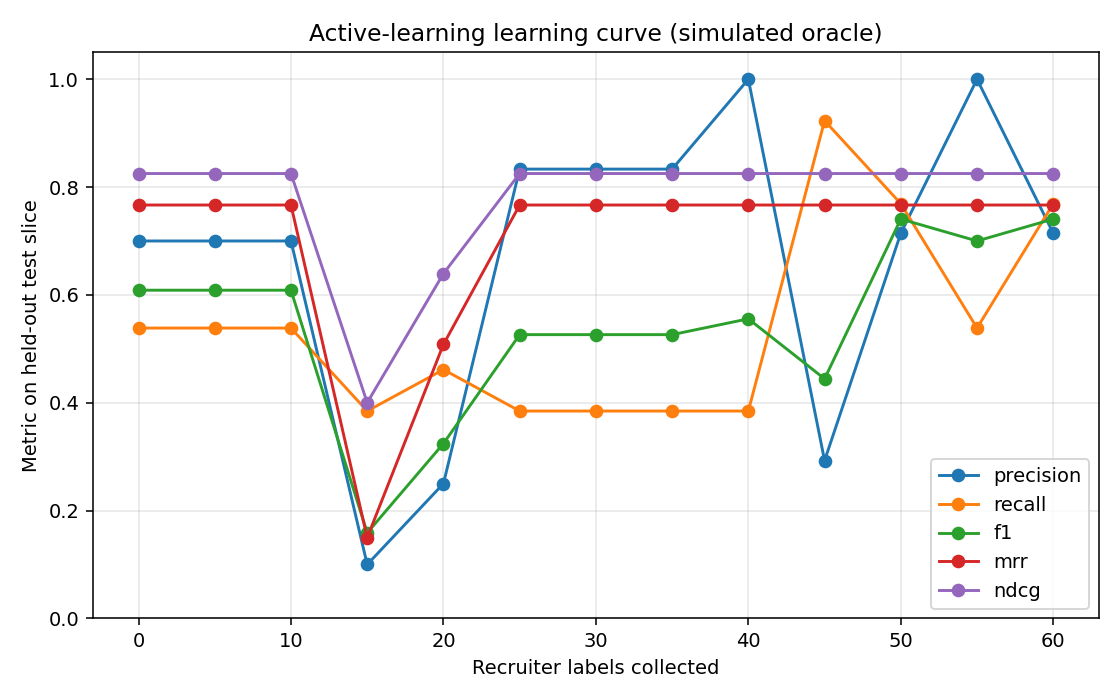

In [10]:
from evaluation.active_learning_eval import plot_curve
from IPython.display import Image

curve = pd.read_csv('evaluation/active_learning_curve.csv')
display(curve)
plot_curve(curve)
Image('evaluation/active_learning_curve.png')

**Optional — regenerate the curve from scratch** (takes a few minutes on CPU).

⚠️ This resets the feedback log as part of the simulation. If you want the seeded feedback back afterward, re-run `!git checkout data/recruiter_feedback.jsonl`.

In [11]:
from evaluation.active_learning_eval import run_active_learning_eval
fresh_curve = run_active_learning_eval(jd_texts, eval_resumes, labels,
                                       rounds=12, queries_per_round=5)
fresh_curve

[eval] pool=240  test=60  (test held out and never queried)
[eval] round 0 (static): {'round': 0, 'feedback_count': 0, 'model': 'static', 'precision': 0.7, 'recall': 0.5385, 'f1': 0.6087, 'mrr': 0.7667, 'ndcg': 0.8251}
[eval] round 1: {'round': 1, 'feedback_count': 5, 'model': 'static (warming up)', 'precision': 0.7, 'recall': 0.5385, 'f1': 0.6087, 'mrr': 0.7667, 'ndcg': 0.8251}  trained=False
[eval] round 2: {'round': 2, 'feedback_count': 10, 'model': 'static (warming up)', 'precision': 0.7, 'recall': 0.5385, 'f1': 0.6087, 'mrr': 0.7667, 'ndcg': 0.8251}  trained=False
[eval] round 3: {'round': 3, 'feedback_count': 15, 'model': 'adaptive', 'precision': 0.1, 'recall': 0.3846, 'f1': 0.1587, 'mrr': 0.1498, 'ndcg': 0.4001}  trained=True
[eval] round 4: {'round': 4, 'feedback_count': 20, 'model': 'adaptive', 'precision': 0.25, 'recall': 0.4615, 'f1': 0.3243, 'mrr': 0.5082, 'ndcg': 0.6395}  trained=True
[eval] round 5: {'round': 5, 'feedback_count': 25, 'model': 'adaptive', 'precision': 0.83

,round,feedback_count,model,precision,recall,f1,mrr,ndcg
0,0,0,static,0.7000,0.5385,0.6087,0.7667,0.8251
1,1,5,static (warming up),0.7000,0.5385,0.6087,0.7667,0.8251
2,2,10,static (warming up),0.7000,0.5385,0.6087,0.7667,0.8251
3,3,15,adaptive,0.1000,0.3846,0.1587,0.1498,0.4001
4,4,20,adaptive,0.2500,0.4615,0.3243,0.5082,0.6395
5,5,25,adaptive,0.8333,0.3846,0.5263,0.7667,0.8251
6,6,30,adaptive,0.8333,0.3846,0.5263,0.7667,0.8251
7,7,35,adaptive,0.8333,0.3846,0.5263,0.7667,0.8251
8,8,40,adaptive,1.0000,0.3846,0.5556,0.7667,0.8251
9,9,45,adaptive,0.2927,0.9231,0.4444,0.7667,0.8251


## 7. Benchmark metrics\n\nThe standard evaluation: Precision, Recall, F1, MRR, NDCG, cosine separation, and timing on the full labelled set.

In [12]:
# (If you ran the optional regen above, restore the seed feedback first.)
!git checkout data/recruiter_feedback.jsonl 2>/dev/null

from evaluation.evaluate import evaluate
metrics = evaluate(jd_texts, eval_resumes, labels)
metrics

{'precision': 0.7826,
 'recall': 0.6,
 'f1': 0.6792,
 'mrr': 1.0,
 'ndcg': 0.9043,
 'cosine_matched_mean': 0.7099,
 'cosine_unmatched_mean': 0.6058,
 'avg_seconds_per_resume': 0.14543}

## 8. (Optional) Launch the interactive dashboard

The Streamlit dashboard is best seen in the video walkthrough, but you can launch it here through a public tunnel if you want to click around. This step can be flaky and is **not required** to verify the project.

When the tunnel URL appears, open it; if it asks for a password, paste the IP printed just above the link.

In [13]:
# OPTIONAL — interactive dashboard via localtunnel
!pip install -q streamlit
!streamlit run dashboard/app.py &>./streamlit_log.txt &
import time; time.sleep(8)
import urllib.request
print("Tunnel password (your Colab public IP):",
      urllib.request.urlopen('https://loca.lt/mytunnelpassword').read().decode())
!npx --yes localtunnel --port 8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 103.7 MB/s eta 0:00:00
Tunnel password (your Colab public IP): 34.50.164.216
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://public-carrots-kick.loca.lt
^C
